# Statistics on Light Curves

- author : Sylvie Dagoret-Campagne
- affiliation : IJCLab/IN2P3/CNRS
- creation date : 2025-11-11 laptop on (**kernel pytorch-cpu-py312**)
- update : 2025-11-09 : finish implementation at NERSC


## Prepare data

In [1]:
import numpy as np
import pandas as pd
from astropy.io import fits
import glob
import random
import fitsio
import os
from typing import Optional,List,Dict,Tuple
import socket
import traceback
import psutil

In [2]:
import matplotlib.pyplot as plt

In [3]:
import sys
print(sys.executable)

/Users/dagoret/miniconda3/envs/pytorch-cpu-py312/bin/python


In [4]:
#!ls /global/cfs/cdirs/lsst/www/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2

## Function definitions

In [5]:
def is_on_system(system_hostnames: List[str], system_env_vars: List[str] = None) -> bool:
    """
    Check if the current environment matches a specific computing system.

    Args:
        system_hostnames: List of substrings to check in the hostname.
        system_env_vars: Optional list of environment variables to check.

    Returns:
        bool: True if the current environment matches the system, False otherwise.
    """
    hostname = socket.gethostname()

    # Check hostname
    host_check = any(system_host in hostname for system_host in system_hostnames)

    # Check environment variables if provided
    env_check = False
    if system_env_vars:
        env_check = any(var in os.environ for var in system_env_vars)

    return host_check or env_check

def is_on_nersc() -> bool:
    """Check if the current environment is a NERSC system."""
    nersc_hostnames = ["perlmutter", "cori", "nersc.gov"]
    nersc_env_vars = ["NERSC_HOST", "CRAY_SYSTEM_NAME"]
    return is_on_system(nersc_hostnames, nersc_env_vars)

def is_on_idris() -> bool:
    """Check if the current environment is an IDRIS Jean-Zay system."""
    idris_hostnames = ["jean-zay", "jean-zay2", "r3i4n5"]
    return is_on_system(idris_hostnames)

def get_system_name() -> str:
    """
    Determine the name of the current computing system.

    Returns:
        str: The name of the system ("NERSC", "IDRIS", or "Other").
    """
    if is_on_nersc():
        return "NERSC"
    elif is_on_idris():
        return "IDRIS"
    else:
        return "Other"

if __name__ == "__main__":
    system = get_system_name()
    if system == "NERSC":
        print("I am on a NERSC system.")
    elif system == "IDRIS":
        print("I am on an IDRIS Jean-Zay system.")
    else:
        print("I am on my laptop or another system.")


I am on my laptop or another system.


In [6]:
def get_datapath() -> Optional[str]:
    """
    Get the appropriate data path based on the current computing environment.

    Returns:
        Optional[str]: The path to the DESC-TD public data directory for the current system.
                       Returns None if the path cannot be determined or doesn't exist.

    Raises:
        EnvironmentError: If the required environment variables are missing on IDRIS.
    """
    # Define base paths for each system
    system_paths = {
        "NERSC": "/global/cfs/cdirs/lsst/www/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2",
        "IDRIS": None,  # Will be constructed dynamically
        "LOCAL": "/Users/dagoret/DATA/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2"
    }

    # Determine the current system
    #from your_module import is_on_nersc, is_on_idris  # Import your system detection functions

    if is_on_nersc():
        print("NERSC configuration: Using NERSC-specific paths.")
        path = system_paths["NERSC"]

    elif is_on_idris():
        print("IDRIS configuration: Using IDRIS-specific paths.")
        try:
            # Get the WORK environment variable
            WORK_PATH = os.getenv("WORK")
            if not WORK_PATH:
                raise EnvironmentError("WORK environment variable not set on IDRIS.")

            # Construct the full path
            relative_path = "DESC/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2"
            #path = os.path.join(WORK_PATH, relative_path)
            path = WORK_PATH + "/DESC/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/"

        except Exception as e:
            print(f"Error determining IDRIS path: {e}")
            return None

    else:
        print("Local configuration: Using local resources.")
        path = system_paths["LOCAL"]

    # Verify the path exists
    if not os.path.exists(path):
        print(f"Warning: The specified path does not exist: {path}")
        return None

    return path


In [7]:
def build_dict_objtype_from_file(path_top: str, obj_type_list: List[str]) -> Dict[str, Dict[str, List[str]]]:
    """
    Build a dictionary mapping each object type to its corresponding ELASTIC2 header and photometric FITS files.

    Parameters
    ----------
    path_top : str
        Root directory containing subdirectories for each object type.
    obj_type_list : List[str]
        List of object type names (each corresponding to a subdirectory).

    Returns
    -------
    Dict[str, Dict[str, List[str]]]
        A dictionary with the following structure:
        {
            "OBJTYPE1": {
                "head_files": ["/path/to/file1_HEAD.FITS.gz", ...],
                "phot_files": ["/path/to/file1_PHOT.FITS.gz", ...]
            },
            ...
        }
    """
    dict_objtype_to_files: Dict[str, Dict[str, List[str]]] = {}

    for obj_type in obj_type_list:
        path = os.path.join(path_top, obj_type)

        if not os.path.isdir(path):
            print(f"⚠️  Warning: directory not found for object type '{obj_type}' — skipping.")
            continue

        head_pattern = os.path.join(path, "*_HEAD.FITS.gz")
        phot_pattern = os.path.join(path, "*_PHOT.FITS.gz")

        head_files = sorted(glob.glob(head_pattern))
        phot_files = sorted(glob.glob(phot_pattern))

        if not head_files and not phot_files:
            print(f"⚠️  No FITS files found in {path}")

        dict_objtype_to_files[obj_type] = {
            "head_files": head_files,
            "phot_files": phot_files
        }

    return dict_objtype_to_files


In [8]:
def load_lightcurve(head_file: str, phot_file: str, lctype: str) -> Tuple[pd.DataFrame, np.recarray]:
    """
    Load a single light curve from ELASTIC2-format FITS files.

    Parameters
    ----------
    head_file : str
        Path to the *_HEAD.FITS.gz file (contains metadata for the light curve).
    phot_file : str
        Path to the *_PHOT.FITS.gz file (contains the photometric time series).
    lctype : str
        Label identifying the light-curve type (e.g., 'Ia', 'Ibc', 'CC').

    Returns
    -------
    df : pandas.DataFrame
        A DataFrame containing:
        - SNID: supernova identifier
        - LCTYPE: light-curve type
        - MJD: Modified Julian Date
        - BAND: photometric band (string)
        - FLUXCAL: calibrated flux
        - FLUXCALERR: flux uncertainty

    head : numpy.recarray
        Header table (from the HEAD FITS extension).
    """
    # Use context managers to ensure files are properly closed
    with fits.open(head_file, memmap=True) as hdul_head, fits.open(phot_file, memmap=True) as hdul_phot:
        head = hdul_head[1].data
        phot = hdul_phot[1].data

        snid = str(head["SNID"][0]).strip()

        # Convert columns to pandas DataFrame efficiently
        #df = pd.DataFrame({
        #    "SNID": snid,
        #    "LCTYPE": lctype,
        #    "MJD": phot["MJD"].byteswap().newbyteorder('<'),
        #    "BAND": np.char.strip(phot["BAND"].astype(str)),
        #    "FLUXCAL": phot["FLUXCAL"].byteswap().newbyteorder('<'),
        #    "FLUXCALERR": phot["FLUXCALERR"].byteswap().newbyteorder('<')
        #})
        df = pd.DataFrame({
            "SNID": snid,
            "LCTYPE": lctype,
            "MJD": phot["MJD"],
            "BAND": np.char.strip(phot["BAND"].astype(str)),
            "FLUXCAL": phot["FLUXCAL"],
            "FLUXCALERR": phot["FLUXCALERR"]
        })


        # Forcer le little-endian pour toutes les colonnes float ou int
        for col in ["MJD", "FLUXCAL", "FLUXCALERR"]:
            df[col] = df[col].astype(df[col].dtype.newbyteorder('<'))

    return df, head


In [9]:
def reduce_lightcurve_noise_advanced(
    df: pd.DataFrame,
    snr_strong: float = 3.0,
    snr_weak: float = 1.0,
    frac_weak_max: float = 0.2,
    min_points_per_band: int = 10
) -> pd.DataFrame:
    """
    Reduce the number of noisy points in a light curve while preserving temporal distribution.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain ["MJD", "BAND", "FLUXCAL", "FLUXCALERR"].
    snr_strong : float
        S/N threshold above which all points are kept.
    snr_weak : float
        S/N threshold below which points are considered weak/noise.
    frac_weak_max : float
        Maximum fraction of weak points to keep.
    min_points_per_band : int
        Minimum number of points to keep per band to avoid empty bands.

    Returns
    -------
    pd.DataFrame
        Filtered DataFrame with reduced noise but preserved temporal coverage.
    """

    reduced_list = []

    for band, d in df.groupby("BAND"):
        snr = np.abs(d["FLUXCAL"]) / d["FLUXCALERR"]

        strong = d[snr >= snr_strong]
        weak = d[snr < snr_weak]
        mid = d[(snr >= snr_weak) & (snr < snr_strong)]

        if len(weak) > 0:
            weak_sorted = weak.sort_values("MJD")
            mjd_diff = np.diff(weak_sorted["MJD"].values)

            # Safe density factor computation
            if len(mjd_diff) == 0 or np.max(mjd_diff) == 0:
                frac_weak = frac_weak_max
            else:
                density_factor = np.median(mjd_diff) / np.max(mjd_diff)
                if np.isnan(density_factor) or density_factor == 0:
                    frac_weak = frac_weak_max
                else:
                    frac_weak = min(frac_weak_max / density_factor, 1.0)

            n_keep = max(min_points_per_band, int(len(weak_sorted) * frac_weak))
            # Uniformly sample weak points
            idx = np.linspace(0, len(weak_sorted) - 1, n_keep, dtype=int)
            weak_sampled = weak_sorted.iloc[idx]
        else:
            weak_sampled = pd.DataFrame(columns=d.columns)

        reduced_band = pd.concat([strong, mid, weak_sampled]).sort_values("MJD")
        reduced_list.append(reduced_band)

    return pd.concat(reduced_list).reset_index(drop=True)


In [10]:
def load_all_lightcurves(
    nf: int,
    dict_objtype_to_files: Dict[str, Dict[str, List[str]]],
    verbose: bool = True
) -> List[Tuple[pd.DataFrame, object]]:
    """
    Load multiple light curves from a structured dictionary of file paths.

    Parameters
    ----------
    nf : int
        Maximum number of light curves to load per object type.
    dict_objtype_to_files : dict
        Dictionary of the form:
        {
            "OBJTYPE1": {
                "head_files": [...],
                "phot_files": [...]
            },
            ...
        }
    verbose : bool, optional
        If True (default), print progress and error messages.

    Returns
    -------
    lightcurves : List[Tuple[pd.DataFrame, object]]
        A list of (dataframe, head) tuples, one per loaded light curve.
    """
    lightcurves = []

    for obj_type, file_dict in dict_objtype_to_files.items():
        head_files = file_dict.get("head_files", [])
        phot_files = file_dict.get("phot_files", [])

        if not head_files or not phot_files:
            if verbose:
                print(f"⚠️  No files found for object type '{obj_type}'. Skipping.")
            continue

        n_to_load = min(nf, len(head_files), len(phot_files))
        if verbose:
            print(f"🔹 Loading {n_to_load} lightcurves for '{obj_type}'...")

        for i, (h, p) in enumerate(zip(head_files[:nf], phot_files[:nf]), start=1):
            try:
                df, head = load_lightcurve(h, p, obj_type)
                lightcurves.append((df, head))
            except Exception as e:
                if verbose:
                    print(f"❌ Error loading {obj_type} [{i}/{n_to_load}] - {h}")
                    print(f"   {e}")
                    # Optional: uncomment to debug deeply
                    # traceback.print_exc()

    if verbose:
        print(f"✅ Loaded {len(lightcurves)} lightcurves total.")

    return lightcurves


In [11]:
def plot_lightcurve(
    df: pd.DataFrame,
    title: str | None = None,
    flux_unit: str = "Flux (FLUXCAL)",
    mjd_offset: float | None = None,
    show_legend: bool = True,
    figsize: tuple[int, int] = (18, 6),
    savepath: str | None = None,
    show: bool = True
) -> None:
    """
    Plot a light curve with error bars for each photometric band,
    using realistic colors for each band.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing at least columns: 'MJD', 'BAND', 'FLUXCAL', 'FLUXCALERR'.
    title : str, optional
        Plot title.
    flux_unit : str, optional
        Label for the y-axis (default: "Flux (FLUXCAL)").
    mjd_offset : float, optional
        Subtract this value from MJD for plotting.
    show_legend : bool, optional
        Whether to show a legend (default: True).
    figsize : tuple[int, int], optional
        Figure size in inches.
    savepath : str, optional
        Path to save the figure.
    show : bool, optional
        Whether to display the figure.
    """

    if df.empty:
        print("⚠️  Empty DataFrame — nothing to plot.")
        return

    required_cols = {"MJD", "BAND", "FLUXCAL", "FLUXCALERR"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in DataFrame: {missing}")

    plt.figure(figsize=figsize)

    # Define realistic colors for bands
    band_colors = {
        "u": "#6A5ACD",   # violet/blue
        "g": "#2E8B57",   # green
        "r": "#DC143C",   # red
        "i": "#FF8C00",   # orange
        "z": "#8B4513",   # brownish
        "Y": "#800000",   # dark red / infrared
    }

    bands = sorted(df["BAND"].unique())

    for band in bands:
        b = band.strip()
        if b == "-":
            continue

        d = df[df["BAND"] == band].sort_values("MJD")
        mjd = d["MJD"] - (mjd_offset if mjd_offset else 0)

        color = band_colors.get(b, "#808080")  # fallback grey if band unknown

        plt.errorbar(
            mjd,
            d["FLUXCAL"],
            yerr=d["FLUXCALERR"],
            fmt="o",
            ms=3,
            color=color,
            label=b,
            alpha=0.8,
            capsize=3,
        )

    plt.xlabel(f"MJD{' - ' + str(mjd_offset) if mjd_offset else ''}")
    plt.ylabel(flux_unit)
    plt.grid(True, linestyle="--", alpha=0.4)

    if title:
        plt.title(title, fontsize=13)

    if show_legend:
        plt.legend(title="Band")

    plt.tight_layout()

    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=150, bbox_inches="tight")
        print(f"💾 Saved plot to: {savepath}")

    if show:
        plt.show()
    else:
        plt.close()


In [12]:
def plot_lightcurve_with_theory(
    df: pd.DataFrame,
    head: np.recarray,
    title: str | None = None,
    flux_unit: str = "Flux (FLUXCAL)",
    mjd_offset: float | None = None,
    show_legend: bool = True,
    figsize: tuple[int, int] = (18, 6),
    savepath: str | None = None,
    show: bool = True
) -> None:
    """
    Plot a light curve with error bars for each photometric band,
    and overlay theoretical peak fluxes from head.
    """
    if df.empty:
        print("⚠️  Empty DataFrame — nothing to plot.")
        return
    required_cols = {"MJD", "BAND", "FLUXCAL", "FLUXCALERR"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in DataFrame: {missing}")

    plt.figure(figsize=figsize)
    band_colors = {
        "u": "#6A5ACD",   # violet/blue
        "g": "#2E8B57",   # green
        "r": "#DC143C",   # red
        "i": "#FF8C00",   # orange
        "z": "#8B4513",   # brownish
        "Y": "#800000",   # dark red / infrared
    }

    # Extract theoretical peak magnitudes from head
    theoretical_peak_mags = {
        band: head[f"SIM_PEAKMAG_{band}"][0]
        for band in ["u", "g", "r", "i", "z", "Y"]
    }

    # Convert theoretical peak magnitudes to fluxes (simplified example)
    # Note: This is a placeholder. You need the correct conversion formula.
    theoretical_peak_fluxes = {
        band: 10**(-0.4 * (mag + 48.6))  # Example: AB magnitude to flux conversion
        for band, mag in theoretical_peak_mags.items()
    }

    # Plot observed data
    bands = sorted(df["BAND"].unique())
    for band in bands:
        b = band.strip()
        if b == "-":
            continue
        d = df[df["BAND"] == band].sort_values("MJD")
        mjd = d["MJD"] - (mjd_offset if mjd_offset else 0)
        color = band_colors.get(b, "#808080")
        plt.errorbar(
            mjd,
            d["FLUXCAL"],
            yerr=d["FLUXCALERR"],
            fmt="o",
            ms=3,
            color=color,
            label=f"{b} (observed)",
            alpha=0.8,
            capsize=3,
        )

        # Plot theoretical peak flux as a horizontal line
        if b in theoretical_peak_fluxes:
            plt.axhline(
                y=theoretical_peak_fluxes[b],
                color=color,
                linestyle="--",
                label=f"{b} (theoretical peak)",
                alpha=0.7,
            )

    plt.xlabel(f"MJD{' - ' + str(mjd_offset) if mjd_offset else ''}")
    plt.ylabel(flux_unit)
    plt.grid(True, linestyle="--", alpha=0.4)
    if title:
        plt.title(title, fontsize=13)
    if show_legend:
        plt.legend(title="Band")
    plt.tight_layout()
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=150, bbox_inches="tight")
        print(f"💾 Saved plot to: {savepath}")
    if show:
        plt.show()
    else:
        plt.close()


In [13]:
def ab_mag_to_njy(mag_ab):
    """Convertit une magnitude AB en flux en nanojansky."""
    return 3631e9 * 10**(-0.4 * mag_ab)

In [14]:

def plot_lightcurve_by_band(
    df: pd.DataFrame,
    head: np.recarray,
    title: str | None = None,
    flux_unit: str = "Flux (FLUXCAL)",
    mjd_offset: float | None = None,
    show_legend: bool = True,
    figsize: tuple[int, int] = (18, 12),
    savepath: str | None = None,
    show: bool = True
) -> None:
    """
    Plot light curves for each band in a 3x2 grid of subplots,
    with shared X-axis (MJD) and theoretical peak fluxes.
    """
    if df.empty:
        print("⚠️  Empty DataFrame — nothing to plot.")
        return
    required_cols = {"MJD", "BAND", "FLUXCAL", "FLUXCALERR"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in DataFrame: {missing}")

    # Define band colors
    band_colors = {
        "u": "#6A5ACD",   # violet/blue
        "g": "#2E8B57",   # green
        "r": "#DC143C",   # red
        "i": "#FF8C00",   # orange
        "z": "#8B4513",   # brownish
        "Y": "#800000",   # dark red / infrared
    }

    # Extract theoretical peak magnitudes from head
    theoretical_peak_mags = {
        band: head[f"SIM_PEAKMAG_{band}"][0]
        for band in ["u", "g", "r", "i", "z", "Y"]
    }

    # Convert theoretical peak magnitudes to fluxes (simplified)
    theoretical_peak_fluxes = {
        #band: 10**(-0.4 * (mag + 48.6))  # Example: AB magnitude to flux
        band : ab_mag_to_njy(mag)
        for band, mag in theoretical_peak_mags.items()
    }


    
    

    # Create subplots
    fig, axes = plt.subplots(3, 2, figsize=figsize, sharex=True)
    fig.suptitle(title, fontsize=14) if title else None

    # Flatten axes for easy iteration
    axes = axes.ravel()

    # Plot each band in a separate subplot
    #for i, band in enumerate(sorted(df["BAND"].unique())):
    for i,band in enumerate(["u", "g", "r", "i", "z", "Y"]):
        b = band.strip()
        if b == "-":
            continue
        ax = axes[i]
        d = df[df["BAND"] == band].sort_values("MJD")
        mjd = d["MJD"] - (mjd_offset if mjd_offset else 0)
        color = band_colors.get(b, "#808080")

        # Plot observed data
        ax.errorbar(
            mjd,
            d["FLUXCAL"],
            yerr=d["FLUXCALERR"],
            fmt="o",
            ms=3,
            color=color,
            label=f"{b} (observed)",
            alpha=0.8,
            capsize=3,
        )

        # Plot theoretical peak flux as a horizontal line
        if b in theoretical_peak_fluxes:
            ax.axhline(
                y=theoretical_peak_fluxes[b],
                color=color,
                linestyle="--",
                label=f"{b} (theoretical peak)",
                alpha=0.7,
            )

        ax.set_title(f"Band {b}")
        ax.set_ylabel(flux_unit)
        ax.grid(True, linestyle="--", alpha=0.4)
        if show_legend:
            ax.legend()

    # Set common x-label
    fig.text(0.5, 0.04, f"MJD{' - ' + str(mjd_offset) if mjd_offset else ''}", ha="center")

    plt.tight_layout()
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=150, bbox_inches="tight")
        print(f"💾 Saved plot to: {savepath}")
    if show:
        plt.show()
    else:
        plt.close()


## Start 

In [15]:
# -----------------------------
# 2️⃣ Définir les chemins NERSC
# -----------------------------

In [16]:
# 2️⃣ Définir le chemin des données et types à analyser
if is_on_nersc():
    print("Configuration pour NERSC : utilisation des GPU ou des chemins spécifiques.")
    # Exemple : charger des données depuis un chemin NERSC
    BASE_PATH = "/global/cfs/cdirs/lsst/www/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2"

if is_on_idris():
    WORK_PATH = os.getenv("WORK")
    #BASE_PATH = os.path.join(WORK_PATH,"/DESC/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/")
    BASE_PATH = WORK_PATH + "/DESC/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/"
else:
    print("Configuration pour laptop : utilisation des ressources locales.")
    # Exemple : charger des données depuis un chemin local
    BASE_PATH = "/Users/dagoret/DATA/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2"

Configuration pour laptop : utilisation des ressources locales.


In [17]:
BASE_PATH = get_datapath()

Local configuration: Using local resources.


In [18]:
print(BASE_PATH)

/Users/dagoret/DATA/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2


In [19]:
# Répertoire d'un type de SN
sample_types = [
    "ELASTICC2_TRAIN_02_SNIa-SALT3",
    "ELASTICC2_TRAIN_02_SNIc-Templates",
    "ELASTICC2_TRAIN_02_SNIb-Templates"]

dict_sntype_to_files = build_dict_objtype_from_file(path_top = BASE_PATH, obj_type_list = sample_types )

In [20]:
#dict_sntype_to_files

In [21]:
# -----------------------------
# 3️⃣ Lire un HEAD aléatoire
# -----------------------------
# select the first type of SN
sntype = list(dict_sntype_to_files.keys())[0]

PATH = os.path.join(BASE_PATH,sntype)

#then specify the path
head_files = dict_sntype_to_files[sntype]["head_files"]

head_file = os.path.join(PATH, random.choice(head_files))
head_data = fitsio.FITS(head_file)[1].read()
print("Colonnes HEAD :", head_data.dtype.names)
print("Exemple HEAD :\n", head_data[:1])

Colonnes HEAD : ('SNID', 'IAUC', 'FAKE', 'RA', 'DEC', 'PIXSIZE', 'NXPIX', 'NYPIX', 'SNTYPE', 'NOBS', 'PTROBS_MIN', 'PTROBS_MAX', 'MWEBV', 'MWEBV_ERR', 'REDSHIFT_HELIO', 'REDSHIFT_HELIO_ERR', 'REDSHIFT_FINAL', 'REDSHIFT_FINAL_ERR', 'VPEC', 'VPEC_ERR', 'HOSTGAL_NMATCH', 'HOSTGAL_NMATCH2', 'HOSTGAL_OBJID', 'HOSTGAL_FLAG', 'HOSTGAL_PHOTOZ', 'HOSTGAL_PHOTOZ_ERR', 'HOSTGAL_SPECZ', 'HOSTGAL_SPECZ_ERR', 'HOSTGAL_RA', 'HOSTGAL_DEC', 'HOSTGAL_SNSEP', 'HOSTGAL_DDLR', 'HOSTGAL_CONFUSION', 'HOSTGAL_LOGMASS', 'HOSTGAL_LOGMASS_ERR', 'HOSTGAL_LOGSFR', 'HOSTGAL_LOGSFR_ERR', 'HOSTGAL_LOGsSFR', 'HOSTGAL_LOGsSFR_ERR', 'HOSTGAL_COLOR', 'HOSTGAL_COLOR_ERR', 'HOSTGAL_ELLIPTICITY', 'HOSTGAL_OBJID2', 'HOSTGAL_SQRADIUS', 'HOSTGAL_OBJID_UNIQUE', 'HOSTGAL_ZPHOT_Q000', 'HOSTGAL_ZPHOT_Q010', 'HOSTGAL_ZPHOT_Q020', 'HOSTGAL_ZPHOT_Q030', 'HOSTGAL_ZPHOT_Q040', 'HOSTGAL_ZPHOT_Q050', 'HOSTGAL_ZPHOT_Q060', 'HOSTGAL_ZPHOT_Q070', 'HOSTGAL_ZPHOT_Q080', 'HOSTGAL_ZPHOT_Q090', 'HOSTGAL_ZPHOT_Q100', 'HOSTGAL_MAG_u', 'HOSTGAL_MAG

### Load a number of SN samples

In [22]:
NF= 50
lightcurves = load_all_lightcurves(NF, dict_sntype_to_files)
print(f"{len(lightcurves)} curves loaded")

🔹 Loading 40 lightcurves for 'ELASTICC2_TRAIN_02_SNIa-SALT3'...
🔹 Loading 40 lightcurves for 'ELASTICC2_TRAIN_02_SNIc-Templates'...
🔹 Loading 40 lightcurves for 'ELASTICC2_TRAIN_02_SNIb-Templates'...
✅ Loaded 120 lightcurves total.
120 curves loaded


### Reduce the light curves

In [23]:
#lightcurves_reduced = []
#count = 0
#for lc,head in lightcurves:
#    count += 1
#    lc_red = reduce_lightcurve_noise_advanced(lc,
#                                              snr_strong=5.0,
#                                              snr_weak=1.0,
#                                              frac_weak_max=0.01,
#                                              min_points_per_band=10)
#    npts = len(lc_red) 
#    if npts>20:
#        lightcurves_reduced.append((lc_red,head)) 
    

## Plot One Light Curve

In [24]:
NLC = len(lightcurves) 
index = np.random.randint(0, NLC)
title_lc = lightcurves[index][0]['LCTYPE'].unique()[0] + " : "  + "SNID " +  str(lightcurves[index][0]['SNID'].unique()[0])

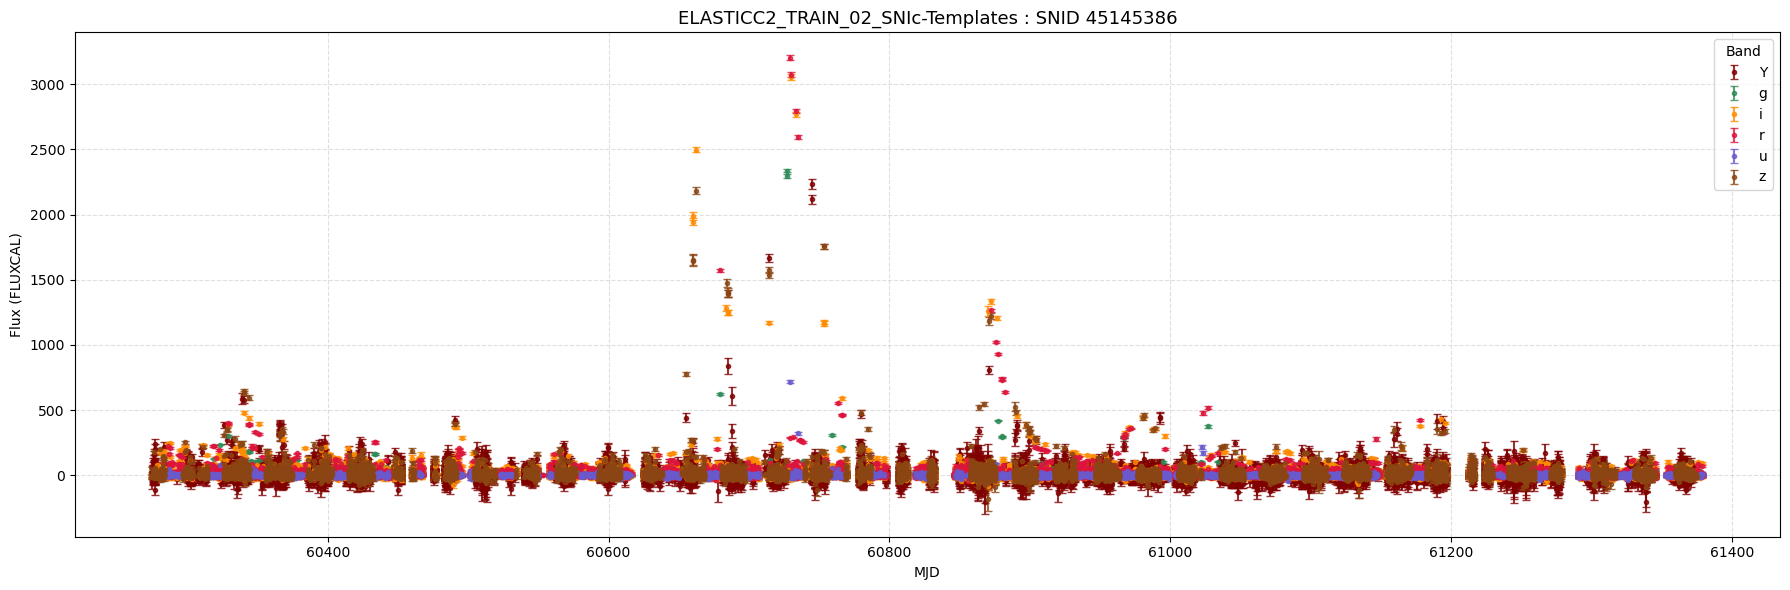

In [25]:
plot_lightcurve(lightcurves[index][0], title=title_lc)

In [26]:
df = lightcurves[index][0]
head = lightcurves[index][1]

In [27]:
df_head = pd.DataFrame(head)

In [28]:
df_head

,SNID,IAUC,FAKE,RA,DEC,PIXSIZE,NXPIX,NYPIX,SNTYPE,NOBS,...,SIM_EXPOSURE_i,SIM_EXPOSURE_z,SIM_EXPOSURE_Y,SIM_GALFRAC_u,SIM_GALFRAC_g,SIM_GALFRAC_r,SIM_GALFRAC_i,SIM_GALFRAC_z,SIM_GALFRAC_Y,SIM_SUBSAMPLE_INDEX
0,45145386,NULL,2,50.750098,-37.073788,0.2,-9,-9,125,233,...,1.0,1.0,1.0,1290.117920,155.073959,72.827812,53.354351,51.536903,58.660000,-9
1,57798687,NULL,2,68.879362,-19.233869,0.2,-9,-9,125,153,...,1.0,1.0,1.0,121.396942,37.759552,25.729998,27.389437,29.182100,49.419579,-9
2,42678940,NULL,2,175.929089,-2.377426,0.2,-9,-9,125,105,...,1.0,1.0,1.0,52.882515,18.007408,16.349705,17.359518,21.566164,28.080669,-9
3,55456497,NULL,2,13.061203,-7.510748,0.2,-9,-9,25,177,...,1.0,1.0,1.0,8.648183,5.259078,6.456728,8.027218,9.351992,14.683836,-9
4,37686399,NULL,2,193.849092,-27.870760,0.2,-9,-9,125,173,...,1.0,1.0,1.0,130.643433,31.618368,33.598972,33.028847,39.190216,45.607037,-9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,54397680,NULL,2,36.360930,-10.333714,0.2,-9,-9,125,30,...,1.0,1.0,1.0,91.114479,3.980104,3.757170,3.928739,5.471283,5.327054,-9
385,56777179,NULL,2,4.632834,-17.966404,0.2,-9,-9,125,122,...,1.0,1.0,1.0,51.767014,6.995039,9.019748,10.561782,12.827230,13.315898,-9
386,42539198,NULL,2,103.800826,-61.407889,0.2,-9,-9,125,174,...,1.0,1.0,1.0,22.960785,0.898886,0.232801,0.349213,0.414361,0.435379,-9
387,7891326,NULL,2,21.763835,-52.101243,0.2,-9,-9,125,125,...,1.0,1.0,1.0,0.005576,0.009836,0.025732,0.046999,0.077912,0.127969,-9


In [29]:
#plot_lightcurve_with_theory(df,head,title = title_lc)

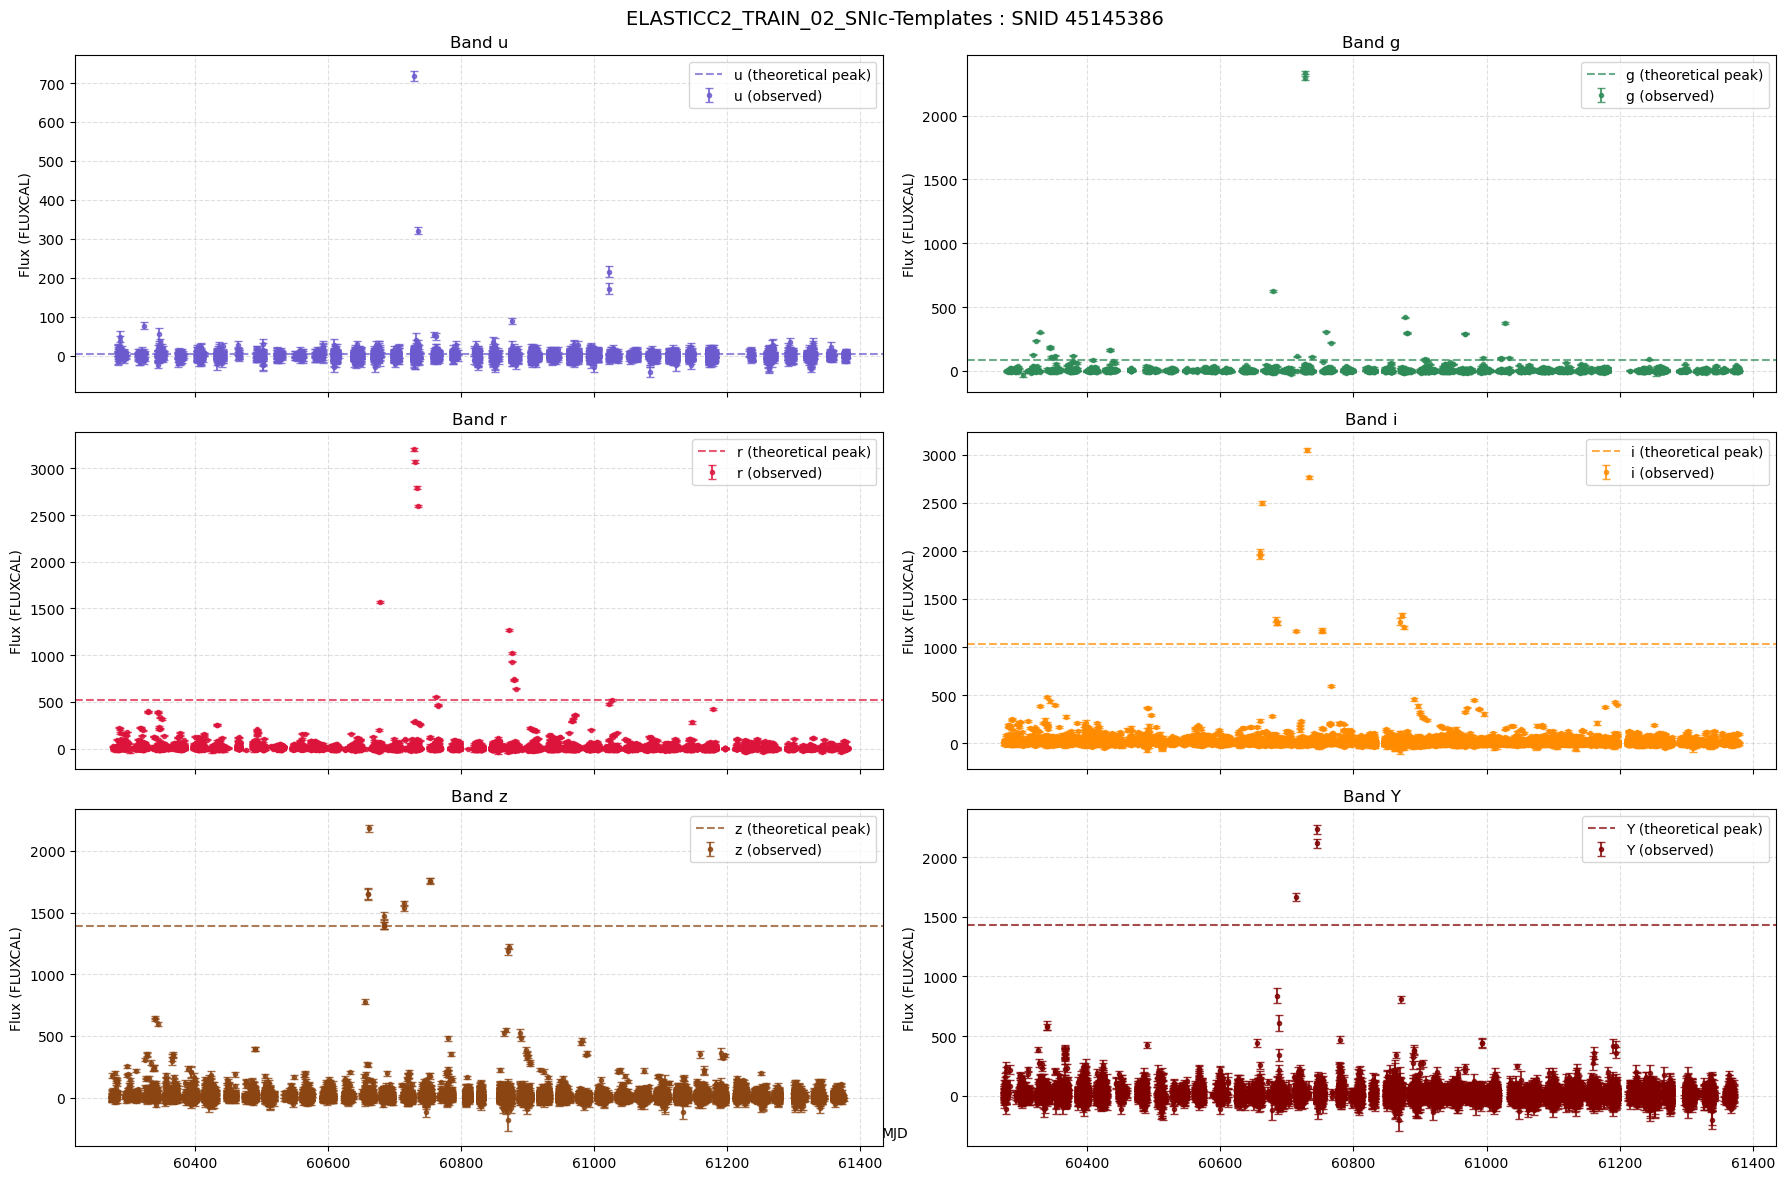

In [30]:
plot_lightcurve_by_band(df,head,title = title_lc)

In [31]:
# Supposons que df soit votre DataFrame contenant les observations
# Colonnes : 'MJD', 'BAND', 'FLUXCAL', 'FLUXCALERR'

# Filtrer les bandes valides
valid_bands = ["u", "g", "r", "i", "z", "Y"]
df_filtered = df[df["BAND"].isin(valid_bands)]


# Définir les bins de 1 jour (24h) sur l'axe des MJD
mjd_min = df_filtered["MJD"].min()
mjd_max = df_filtered["MJD"].max()
bins = np.arange(mjd_min, mjd_max + 1, 1)  # Bins de 1 jour
mjd_delta = mjd_max - mjd_min

In [32]:
print(mjd_delta)

1104.1178999999975


In [33]:
# Initialiser un dictionnaire pour stocker les histogrammes
histograms = {}

# Calculer l'histogramme pour chaque bande
for band in valid_bands:
    band_data = df_filtered[df_filtered["BAND"] == band]
    counts, _ = np.histogram(band_data["MJD"], bins=bins)
    histograms[band] = counts

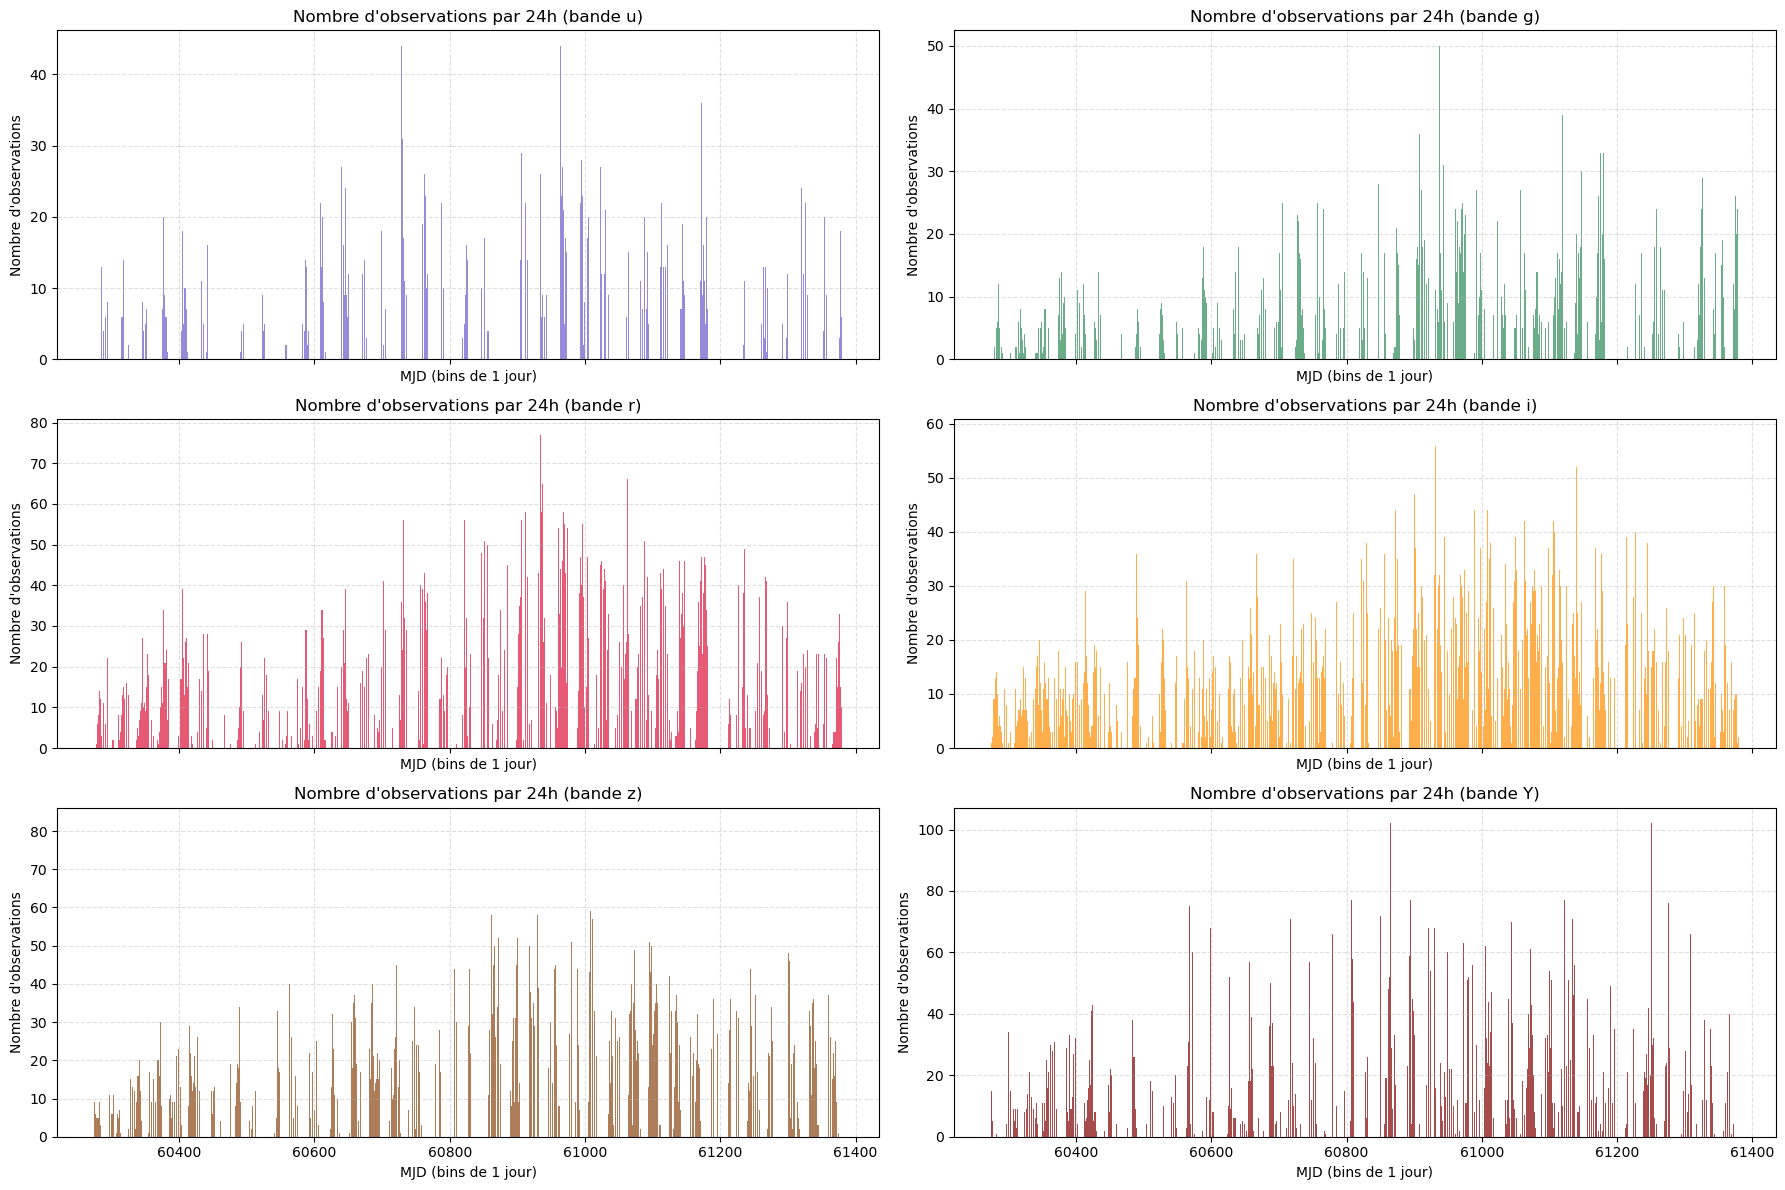

In [34]:
# Définir les couleurs pour chaque bande
band_colors = {
    "u": "#6A5ACD",   # violet/blue
    "g": "#2E8B57",   # green
    "r": "#DC143C",   # red
    "i": "#FF8C00",   # orange
    "z": "#8B4513",   # brownish
    "Y": "#800000",   # dark red / infrared
}

# Créer une figure avec des sous-graphiques (3x2)
fig, axes = plt.subplots(3, 2, figsize=(18, 12), sharex=True)
axes = axes.ravel()

# Tracer l'histogramme pour chaque bande
for i, band in enumerate(valid_bands):
    ax = axes[i]
    ax.bar(
        bins[:-1],  # Utiliser le bord gauche de chaque bin
        histograms[band],
        color=band_colors[band],
        alpha=0.7,
        width=0.8,  # Largeur des barres
    )

    ax.set_title(f"Nombre d'observations par 24h (bande {band})")
    ax.set_xlabel("MJD (bins de 1 jour)")
    ax.set_ylabel("Nombre d'observations")
    ax.grid(True, linestyle="--", alpha=0.4)

# Ajuster la disposition
plt.tight_layout()
plt.show()
